# [LAB-02] 3. KMeans 튜닝・평가 - 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import crosstab

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


## 📚 종 이름을 지우고 다시 찾는 펭귄 무리

### 당신은 남극 팔머 기지의 생태 데이터 분석가입니다.

선배 연구원들이 관측한 펭귄 333마리의 부리 길이·부리 두께·날개 길이·몸무게와 서식하는 섬, 성별이 `penguins` 데이터로 정리되어 있고, 개체마다 선배들이 눈으로 판별해 붙인 종 이름도 함께 적혀 있습니다.

팀장은 "앞으로 새로 발견될 개체군에는 붙여 줄 종 이름이 없다"며, 종 이름을 지운 채 신체 치수만으로 무리가 몇 개로 갈리는지 확인해 보라고 합니다. 정답을 보면서 나누면 그건 군집이 아니라 분류이므로 종 이름은 분석에서 빼야 하고, 거리를 계산해야 하니 문자로 적힌 성별과 서식지는 숫자로 바꿔 두어야 합니다.

몇 개의 무리로 나누는 것이 적절한지 근거를 갖춰 판단하고, 그 결과가 선배들의 종 구분과 얼마나 맞아떨어지는지까지 확인하세요.

### 💻 코드 작성

#### 데이터 가져오기

In [2]:
origin = load_data("penguins")
origin.head()

📚 남극 팔머 군도의 펭귄 3종에 대해 신체 치수와 서식지 정보(출처: https://www.kaggle.com/datasets/larsen0966/penguins)

    field              description
--  -----------------  -------------
 0  species            팽귄 종
 1  island             서식지
 2  bill_length_mm     부리 길이
 3  bill_depth_mm      부리 두께
 4  flipper_length_mm  날개 길이
 5  body_mass_g        몸무게
 6  sex                성별



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.100,18.700,181,3750,MALE
1,Adelie,Torgersen,39.500,17.400,186,3800,FEMALE
2,Adelie,Torgersen,40.300,18.000,195,3250,FEMALE
3,Adelie,Torgersen,36.700,19.300,193,3450,FEMALE
4,Adelie,Torgersen,39.300,20.600,190,3650,MALE


#### 데이터 전처리 (품종 제거 / 성별과 서식지 라벨링 및 인코딩)

In [3]:
df1 = origin.drop(columns=['species'])
df2 = my_prep.labeling(df1, ['sex', 'island'])
df3 = my_prep.dummies(df2, ['sex', 'island'])

print(f"\n군집분석에 사용할 변수 개수: {df3.shape[1]}개")

df3.head()

sex (2종): FEMALE=0, MALE=1
island (3종): Biscoe=0, Dream=1, Torgersen=2
island (3종) -> 2개: island_1, island_2  (기준: 0 제외)
sex (2종) -> 생략: 이진 변수이므로 원래 컬럼을 유지

컬럼 수: 6개 -> 7개

군집분석에 사용할 변수 개수: 7개


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_1,island_2
0,39.100,18.700,181,3750,1,0,1
1,39.500,17.400,186,3800,0,0,1
2,40.300,18.000,195,3250,0,0,1
3,36.700,19.300,193,3450,0,0,1
4,39.300,20.600,190,3650,1,0,1


#### 최적 k 탐색

StandardScaler 적용 (7개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
bill_length_mm       32.10 ~ 59.60          -2.18 ~ 2.86
bill_depth_mm       13.10 ~ 21.50          -2.07 ~ 2.20
flipper_length_mm     172.00 ~ 231.00          -2.07 ~ 2.15
body_mass_g    2700.00 ~ 6300.00          -1.87 ~ 2.60
sex                  0.00 ~ 1.00          -1.01 ~ 0.99
island_1             0.00 ~ 1.00          -0.77 ~ 1.31
island_2             0.00 ~ 1.00          -0.41 ~ 2.47


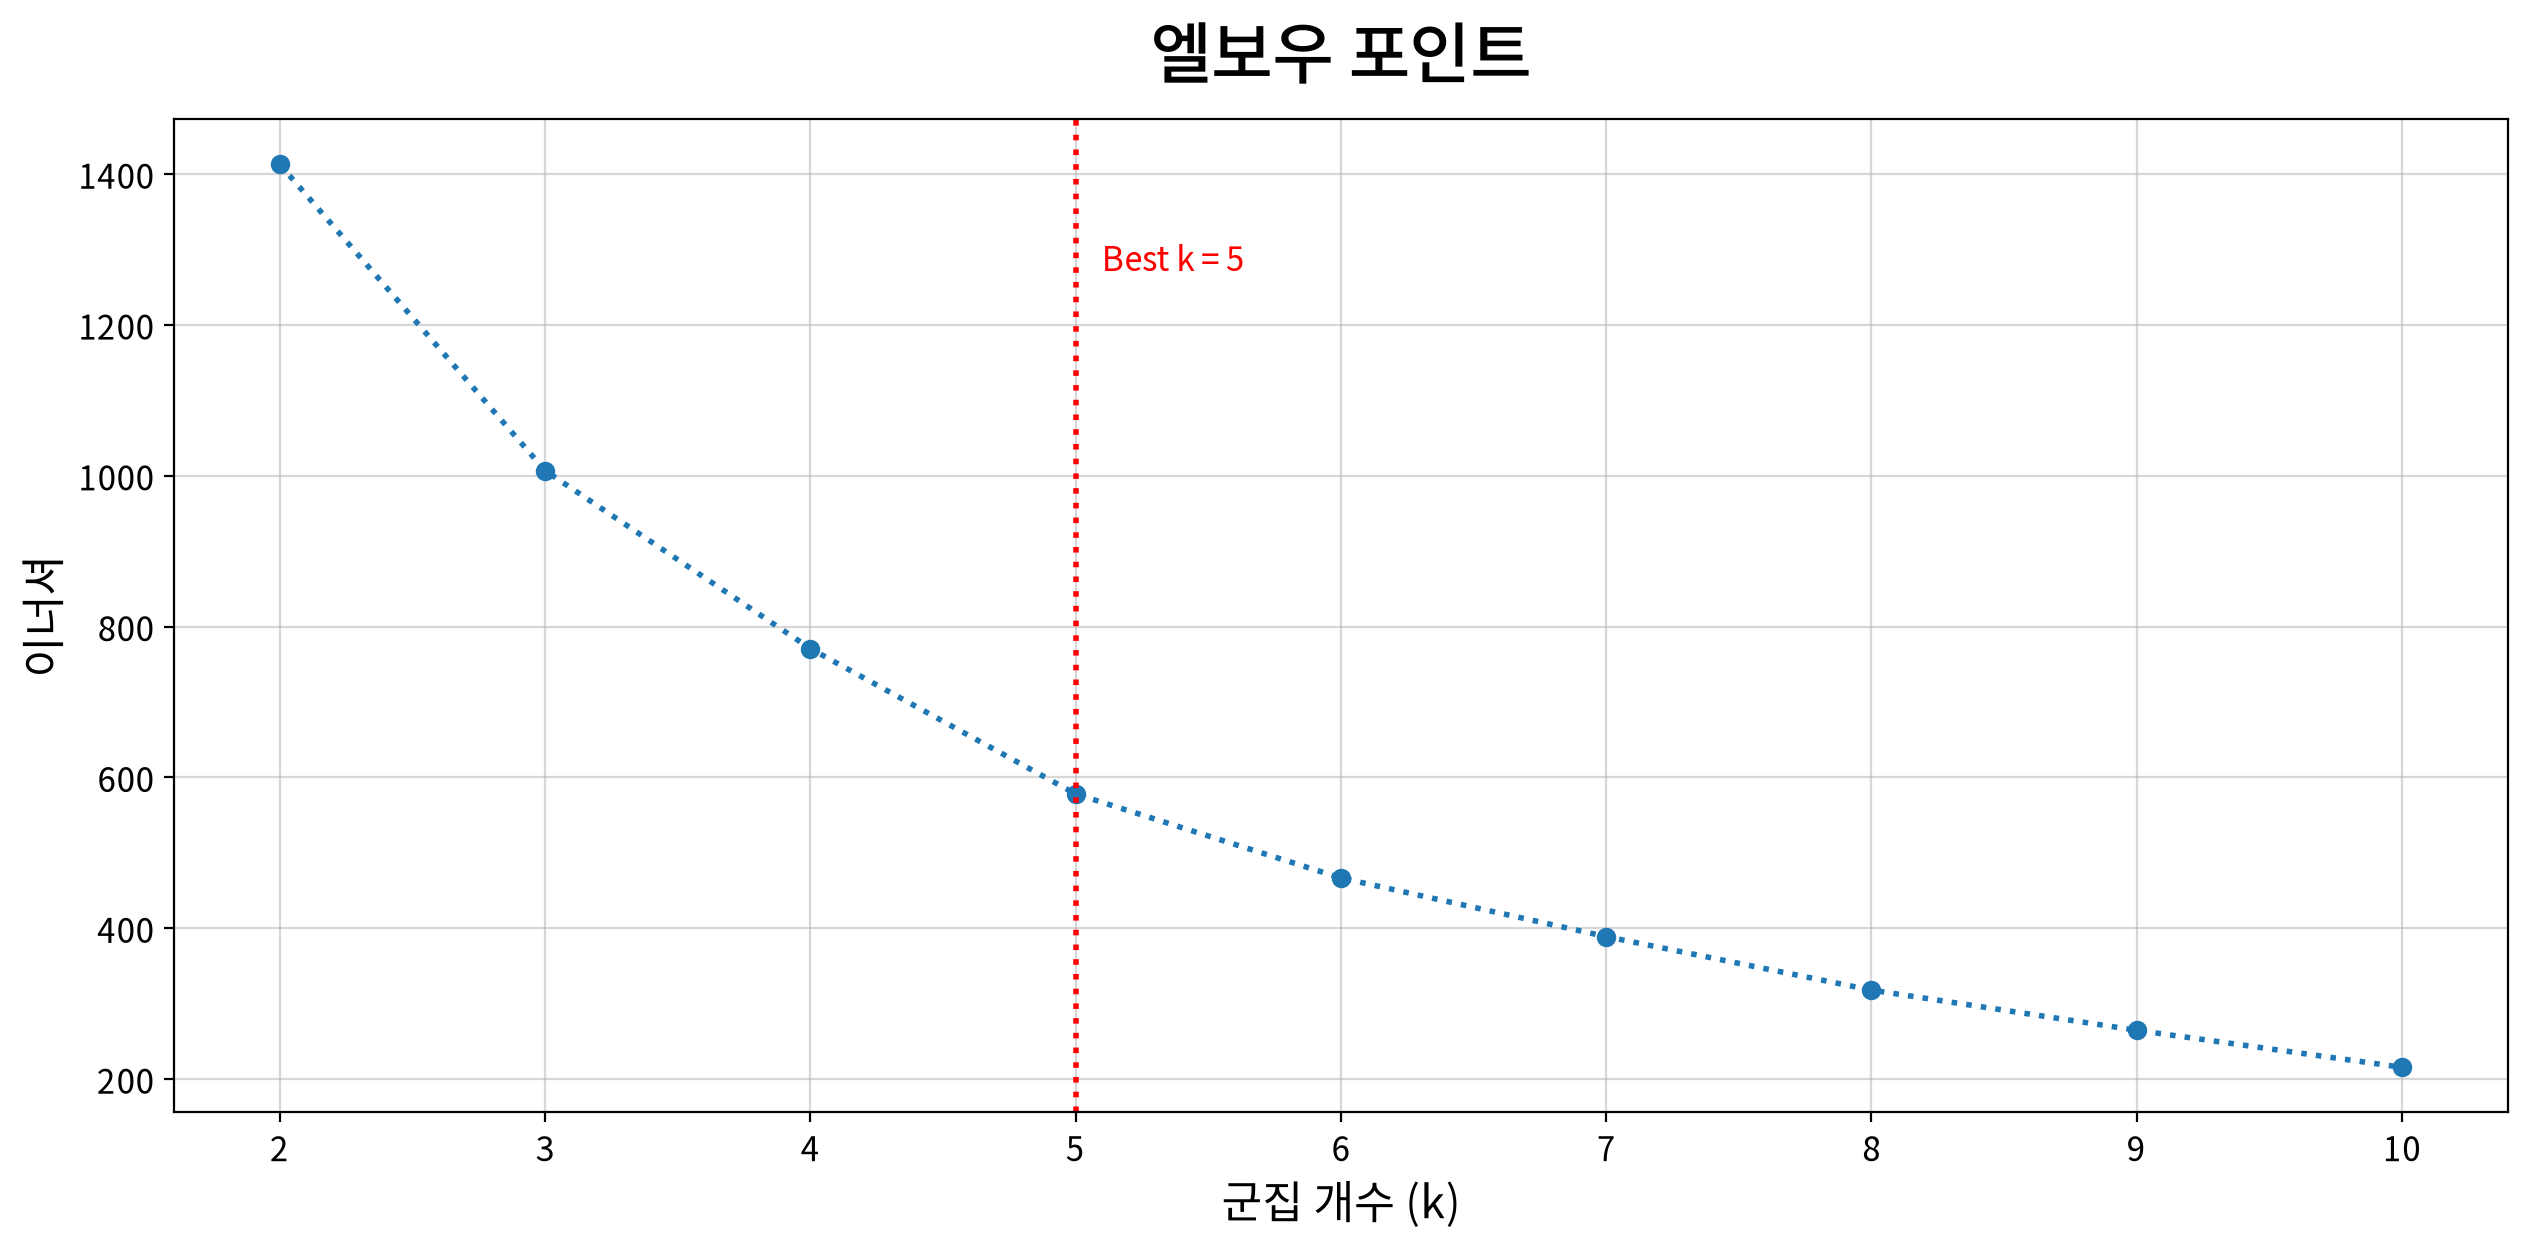

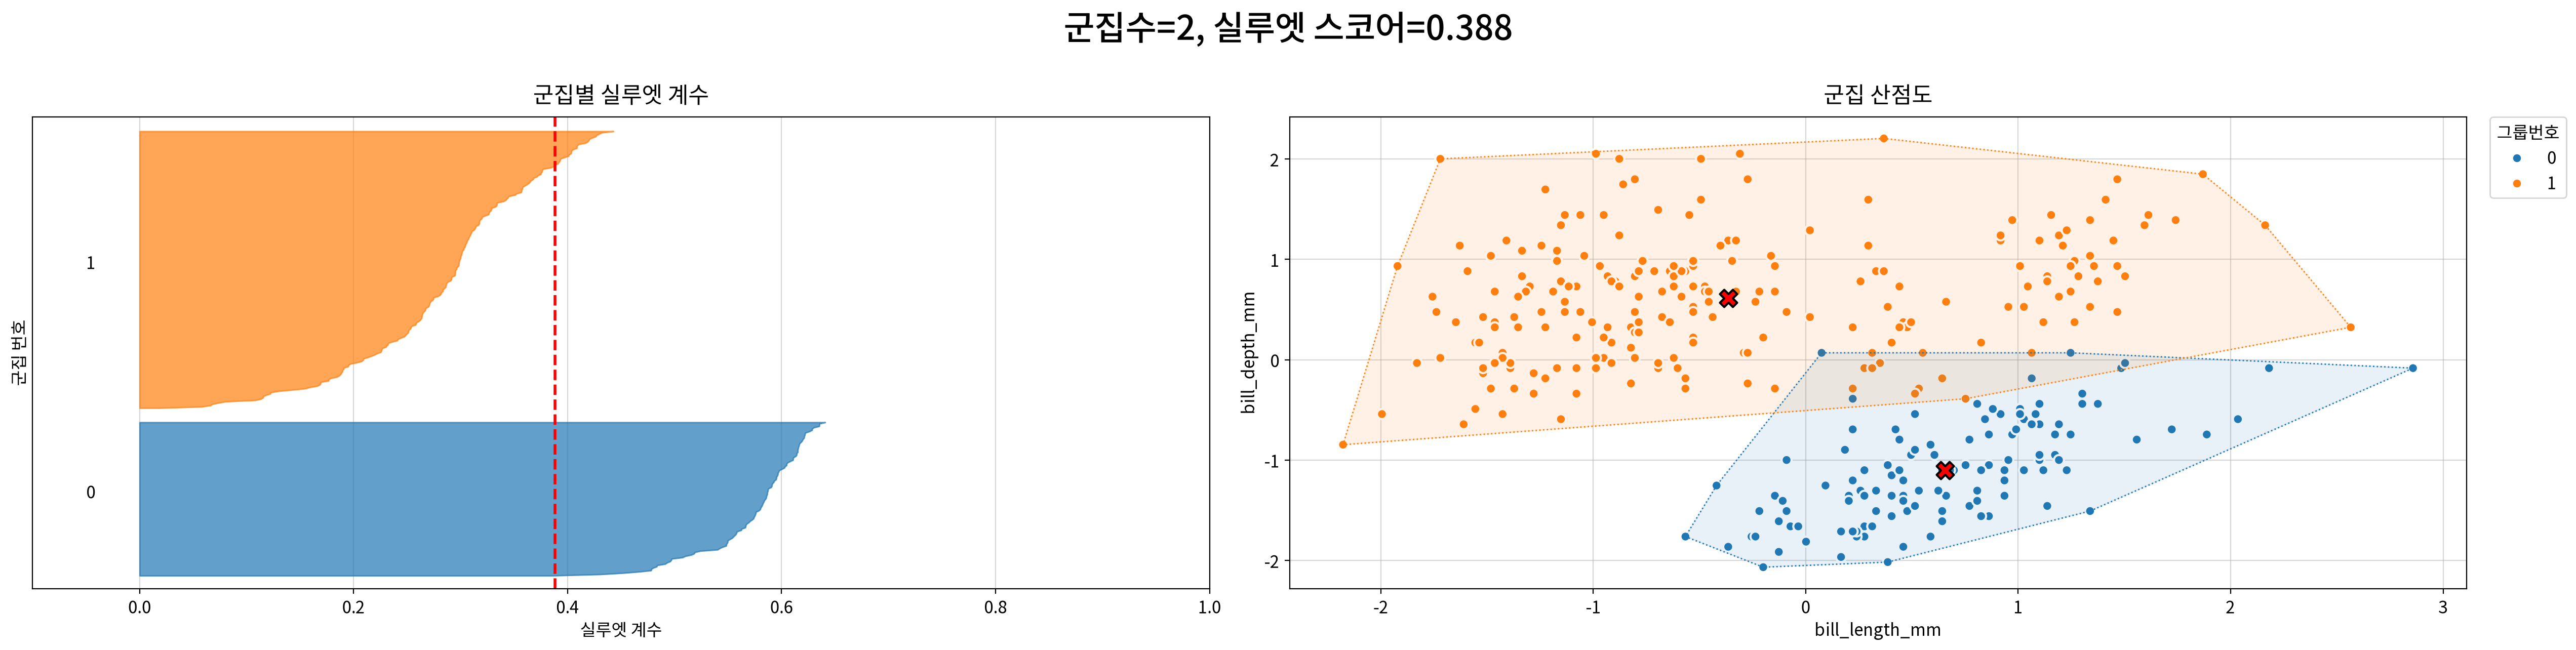

[1단계] 엘보우 포인트   : k = 5  (뭉침만 확인 → 후보)
[2단계] 실루엣 균형지수 : k = 2  (뭉침 + 분리 + 크기 균형)
------------------------------------------------------------
두 지표가 다른 k를 가리킵니다.
  · k = 5 : 균형지수 0.188 (스코어 0.4674, 두께비 1.7872)
  · k = 2 : 균형지수 0.2041 (스코어 0.3884, 두께비 1.7983)
------------------------------------------------------------
>>> 최종 선택: k = 2
    (지표는 후보를 좁혀줄 뿐이므로, 목적과 도메인 지식으로 한 번 더 확인할 것)


,k,이너셔,감소량,스코어,전체면적,두께비,최소상대면적,균형지수
0,2,1412.734,NaN,0.388,129.329,1.798,0.945,0.204
1,3,1006.795,405.938,0.436,145.111,3.553,0.506,0.062
2,4,770.757,236.038,0.428,142.439,2.532,0.628,0.106
3,5,578.074,192.683,0.467,155.657,1.787,0.719,0.188
4,6,466.634,111.439,0.484,161.340,1.409,0.484,0.167
5,7,388.906,77.729,0.492,163.713,2.773,0.512,0.091
6,8,317.954,70.951,0.514,171.238,2.773,0.544,0.101
7,9,264.683,53.271,0.541,180.161,2.773,0.577,0.113
8,10,215.605,49.078,0.554,184.502,2.773,0.583,0.116


In [4]:
final_k, k_df = my_cluster.best_k(df3)
k_df

#### 지표별로 가장 좋은 k 확인

In [5]:
print(f"실루엣 스코어가 가장 높은 k : {int(k_df.loc[k_df['스코어'].idxmax(), 'k'])}")
print(f"두께비가 가장 큰 k          : {int(k_df.loc[k_df['두께비'].idxmax(), 'k'])}")
print(f"균형지수가 가장 높은 k      : {int(k_df.loc[k_df['균형지수'].idxmax(), 'k'])}")
print(f"최종 선택된 k               : {final_k}")

실루엣 스코어가 가장 높은 k : 10
두께비가 가장 큰 k          : 3
균형지수가 가장 높은 k      : 2
최종 선택된 k               : 2


#### 최종 k로 군집화하고 실제 종과 대조

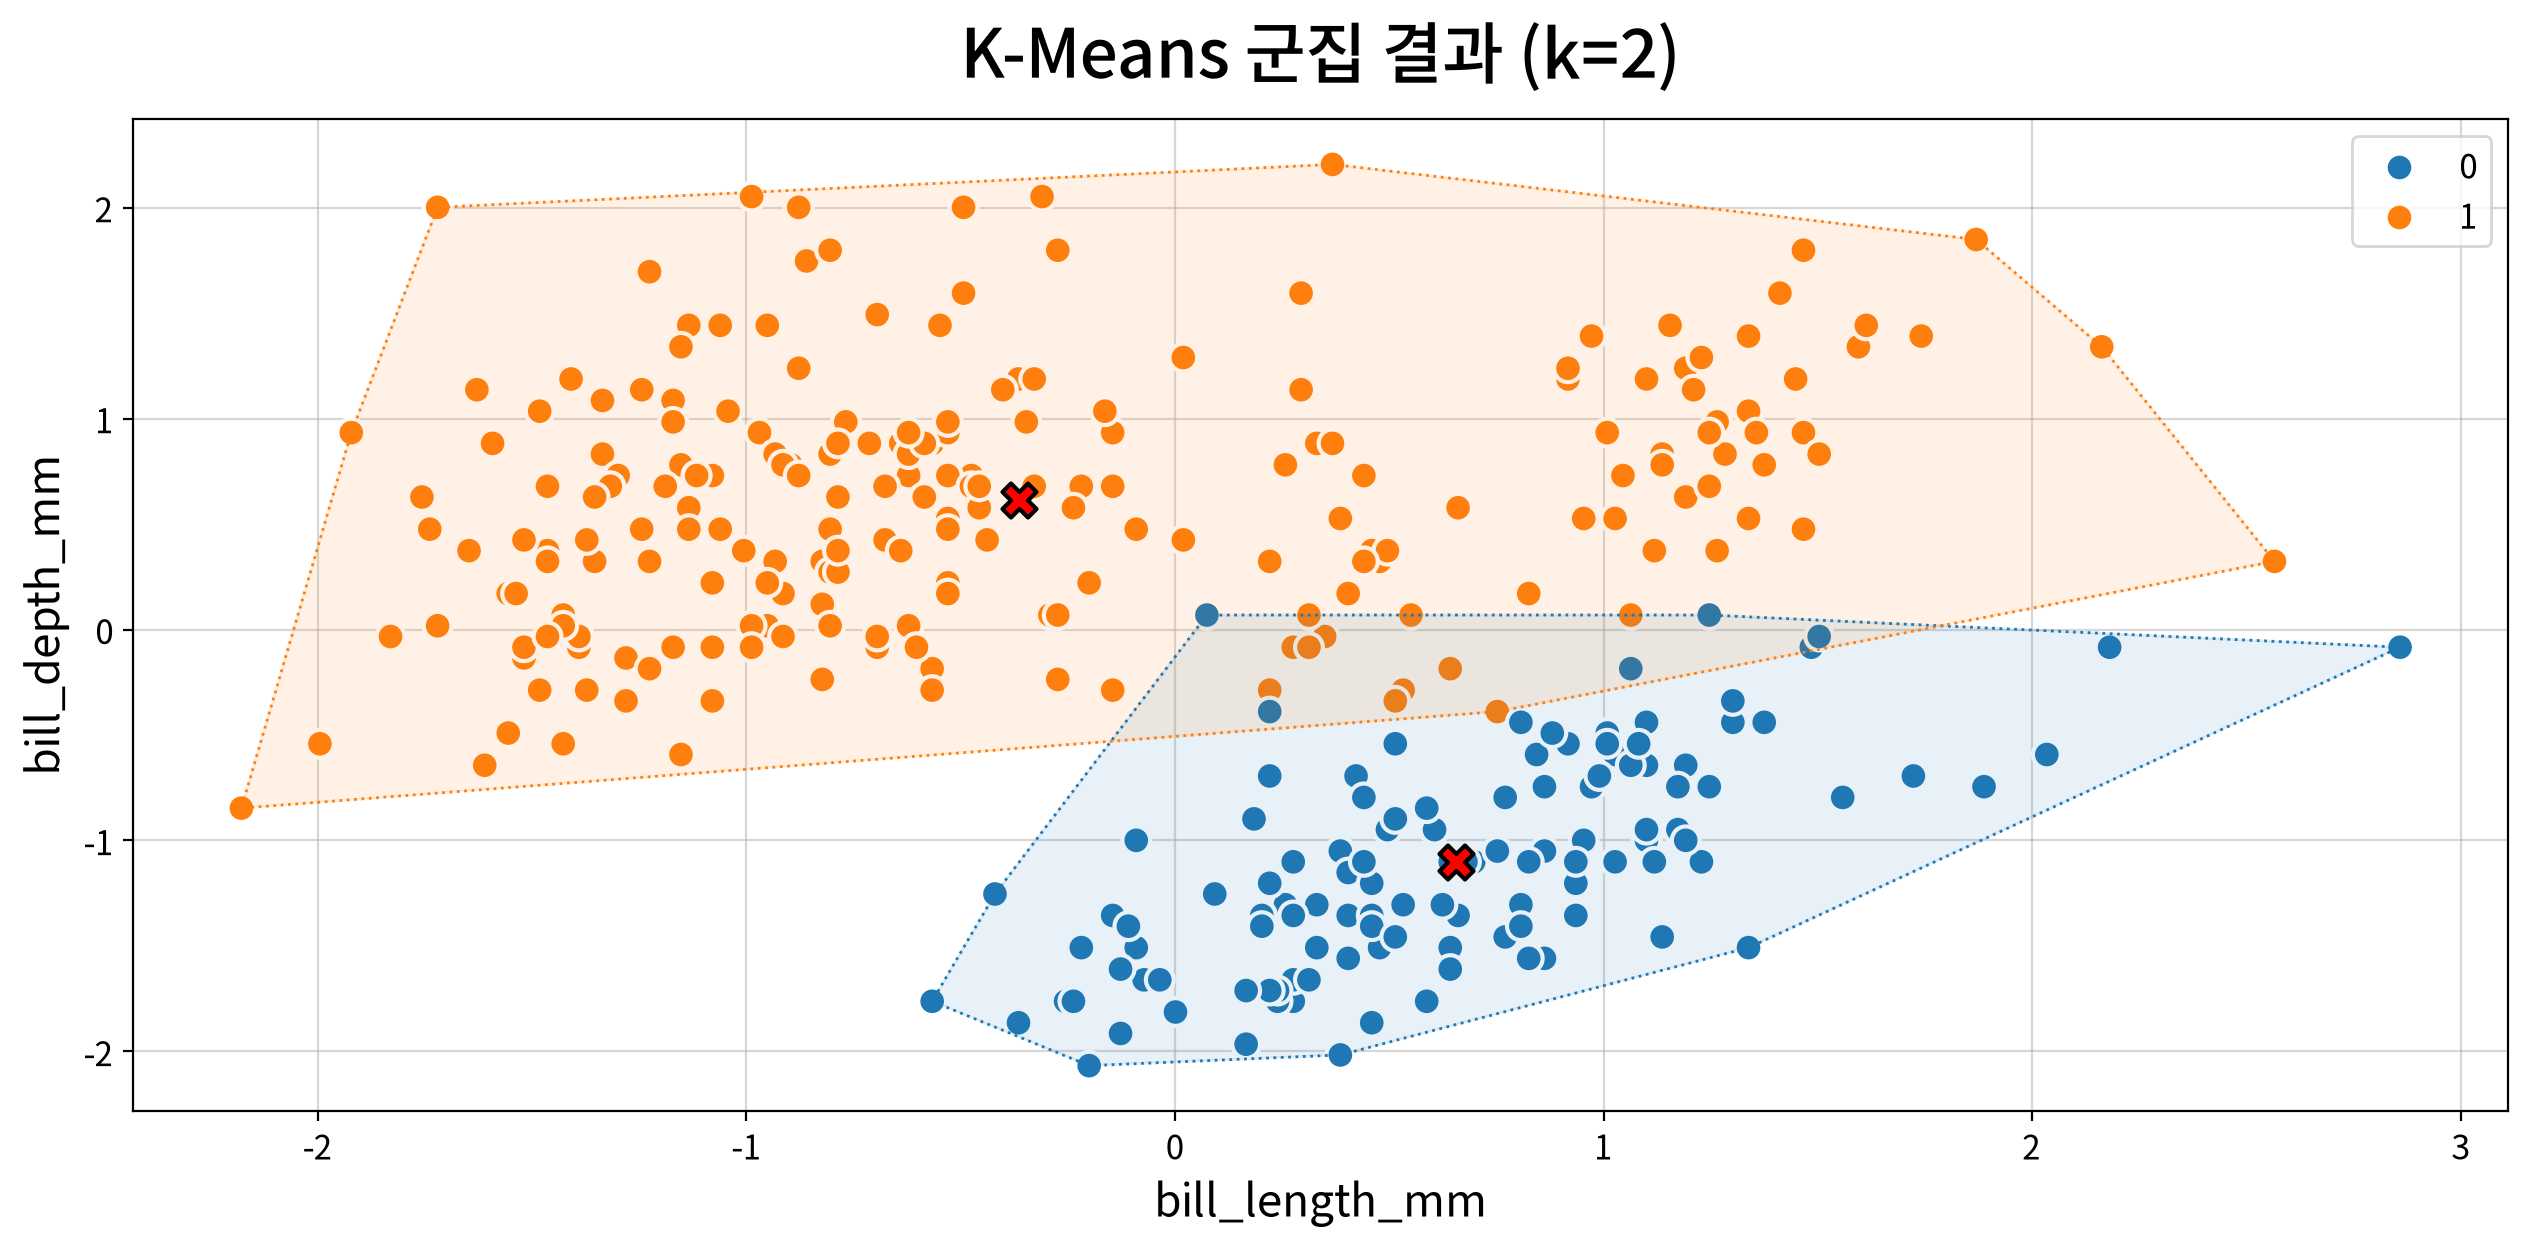

species,Adelie,Chinstrap,Gentoo
그룹번호,,,
0,0,0,119
1,146,68,0


In [6]:
estimator, df4, center_df = my_cluster.kmeans(df3, k=final_k, verbose=False)

crosstab(df4['그룹번호'], origin['species'])

### 문제 풀이

#### 1. 선배들이 붙여 둔 종 이름은 분석에서 빼고, 문자로 적힌 성별과 서식지는 숫자로 바꿨습니다. 이 전처리를 마치고 나면 군집분석에 들어가는 변수는 모두 몇 개인가요? (개)

- **정답**: `7`
- **복습 개념**: 군집분석에 넣을 변수를 고르고 다듬는 단계입니다. 군집분석은 거리를 재서 가까운 것끼리 묶는 방법이라, ① 정답에 해당하는 컬럼은 빼야 하고 ② 문자로 된 값은 숫자로 바꿔야 합니다. 이때 값이 2종인 컬럼과 3종 이상인 컬럼의 처리 방식이 다릅니다.
- **풀이 접근**: 먼저 종 이름 컬럼을 뺍니다(6개 남습니다). 그다음 성별과 서식지를 숫자로 바꾸는데, 성별은 두 종류뿐이라 0과 1 한 컬럼으로 끝납니다. 반면 서식지는 세 종류라 0·1·2로 두면 "Torgersen이 Biscoe보다 2만큼 크다"는 없던 순서가 생기므로, 종류마다 0/1 컬럼으로 펼치되 기준이 되는 한 종류는 빼고 만듭니다.
- **근거(계산 결과)**: 종을 뺀 6개에서 성별은 그대로 1개로 유지되고, 서식지 1개가 2개로 펼쳐집니다. 6 − 1 + 2 = **7개**입니다. 출력의 `island (3종) -> 2개: island_1, island_2  (기준: 0 제외)`, `sex (2종) -> 생략: 이진 변수이므로 원래 컬럼을 유지`, 그리고 `군집분석에 사용할 변수 개수: 7개`로 확인됩니다.
- **헷갈리기 쉬운 점**: 서식지가 3종이니 3개 컬럼이 생긴다고 답하기 쉽습니다. 세 컬럼을 모두 만들면 셋을 더한 값이 항상 1이 되어 두 개만 알면 나머지 하나가 자동으로 정해지므로, 하나를 기준으로 빼고 2개만 만듭니다. 반대로 성별처럼 값이 2종인 컬럼은 라벨링만으로 이미 0/1이 되었으니 더 펼칠 것이 없습니다.

#### 2. 무리의 개수를 하나씩 늘려 가며 "각 무리가 얼마나 촘촘히 뭉쳤는가"를 재면, 어느 순간부터 더 늘려도 이득이 크지 않아집니다. 이렇게 감소폭이 꺾이는 지점으로 좁혀진 후보는 무리 몇 개인가요? (개)

- **정답**: `5`
- **복습 개념**: 엘보우 포인트입니다. 뭉침의 정도(이너셔)는 무리를 늘리면 무조건 줄어들기 때문에 가장 작은 값을 고르는 것은 의미가 없고, "하나 더 늘려도 이제 별 이득이 없어지는" 지점을 찾습니다.
- **풀이 접근**: 2개부터 10개까지 나눠 보며 뭉침의 정도를 모으고, 하나 늘릴 때마다 그 값이 얼마나 줄었는지를 봅니다. 감소량이 뚝 떨어지며 곡선이 팔꿈치처럼 꺾이는 위치를 읽습니다.
- **근거(계산 결과)**: 결과표의 감소량은 405.9 → 236.0 → 192.7 → 111.4 → 77.7 → 71.0 → 53.3 → 49.1로 줄어듭니다. 곡선이 꺾이는 지점은 **5개**이며, 출력의 `[1단계] 엘보우 포인트   : k = 5  (뭉침만 확인 → 후보)`로 확인됩니다.
- **함께 생각해 볼 점**: 출력에 굳이 "후보"라고 적혀 있는 이유를 생각해 보세요. 뭉침의 정도는 각 무리가 자기 중심 가까이 모여 있는지만 보고, 옆 무리와 충분히 떨어져 있는지는 전혀 보지 않습니다. 그래서 이 값 하나로는 최종 결정을 내릴 수 없습니다.

#### 3. "자기 무리와는 가깝고 옆 무리와는 먼가"를 데이터 하나마다 점수로 매긴 뒤 그 평균 하나만 놓고 가장 높은 것을 고른다면, 무리 몇 개가 뽑히나요? (개)

- **정답**: `10`
- **복습 개념**: 실루엣 스코어입니다. 뭉침만 보는 이너셔와 달리 분리까지 함께 보지만, 평균값 하나로 압축된 지표라 최댓값만 쫓으면 엉뚱한 답에 도달합니다.
- **풀이 접근**: 2개부터 10개까지 각각에 대해 실루엣 스코어를 계산한 뒤, 그 열에서 가장 큰 값을 갖는 행의 무리 개수를 읽습니다.
- **근거(계산 결과)**: 스코어는 0.388(2개) → 0.436 → 0.428 → 0.467 → 0.484 → 0.492 → 0.514 → 0.541 → **0.554(10개)** 로, 중간에 살짝 출렁일 뿐 전체적으로 계속 오릅니다. 최댓값은 **10개**이며 출력의 `실루엣 스코어가 가장 높은 k : 10`으로 확인됩니다.
- **자주 하는 실수**: "실루엣 스코어가 높을수록 좋은 군집"이라고 외워 두면 여기서 10개를 정답으로 채택하게 됩니다. 잘게 쪼갤수록 각 무리는 작고 촘촘해져서 점수가 오르기 마련이라, 최댓값만 보면 확인 범위의 끝까지 밀려갑니다. 만약 20개까지 확인했다면 답은 20에 가까워졌을 것입니다. 점수가 범위의 끝에서 최대라면 그건 "20개가 최적"이 아니라 "이 지표만으로는 못 고른다"는 신호입니다.

#### 4. 확인한 2~10개 중, 가장 큰 무리가 가장 작은 무리보다 몇 배나 두꺼운지를 비교하면 크기 불균형이 가장 심했던 것은 무리 몇 개로 나눴을 때인가요? (개)

- **정답**: `3`
- **복습 개념**: 군집 크기의 균형입니다. 실루엣 점수가 높아도 한 무리에만 개체가 몰려 있으면 실무에서 쓸 수 없는 결과이므로, 가장 큰 무리 ÷ 가장 작은 무리(두께비)로 쏠림을 함께 확인합니다.
- **풀이 접근**: 무리 개수별로 각 무리의 개체 수를 세어 최대와 최소의 비율을 구한 뒤, 그 값이 가장 큰 행을 찾습니다. 1에 가까울수록 고르게 나뉜 것입니다.
- **근거(계산 결과)**: 두께비는 1.798(2개), **3.553(3개)**, 2.532(4개), 1.787(5개), 1.409(6개)… 로 3개일 때가 가장 큽니다. 그 결과 균형지수도 0.062로 전 구간 중 가장 낮게 깎였습니다. 출력의 `두께비가 가장 큰 k : 3`으로 확인됩니다.
- **함께 생각해 볼 점**: 실제 펭귄은 3종인데, 하필 3개로 나눴을 때 크기 균형이 가장 나쁘다는 점이 흥미롭습니다. 지표가 나쁘다고 해서 그 답이 틀린 것은 아닙니다. 지표는 데이터가 어떻게 생겼는지를 말해 줄 뿐, 현실의 정답을 알고 있지는 않습니다.

#### 5. 뭉침만 본 후보와 평균 점수만 본 답이 서로 다릅니다. 분리와 크기 균형까지 함께 반영한 지표로 내린 최종 판단은 무리 몇 개인가요? (개)

- **정답**: `2`
- **복습 개념**: 여러 지표가 엇갈릴 때의 최종 판정입니다. 뭉침만 보는 지표는 후보를 좁히는 데 그치고, 뭉침·분리·크기 균형을 함께 본 균형지수가 최종 근거가 됩니다.
- **풀이 접근**: 실루엣 스코어에 크기 균형을 곱해 깎은 균형지수 열을 만들고, 그 값이 가장 큰 행의 무리 개수를 읽습니다.
- **근거(계산 결과)**: 균형지수는 **0.204(2개)**, 0.062(3개), 0.106(4개), 0.188(5개), 0.167(6개), 0.091(7개)… 로 2개일 때 가장 높습니다. 스코어 자체는 0.388로 가장 낮은 편인데도 최소상대면적 0.945, 두께비 1.798로 쏠림이 거의 없어 깎이는 폭이 작았기 때문입니다. 출력의 `>>> 최종 선택: k = 2`로 확인됩니다.
- **실무 포인트**: 엘보우는 5개, 평균 점수는 10개, 균형지수는 2개를 가리켰습니다. 세 지표가 모두 다른 답을 냈다는 사실 자체가 중요한 정보입니다. 이 데이터에는 "명백히 이것"이라고 할 만한 무리 개수가 없다는 뜻이며, 이럴 때 숫자 하나만 뽑아 보고하면 근거 없는 확신을 파는 셈이 됩니다.

#### 6. 최종적으로 채택한 개수로 펭귄들을 나눈 뒤 선배들이 붙여 둔 종 이름과 맞춰 보면, 한 무리를 통째로 차지하며 완벽하게 분리된 종은 무엇인가요?

- **정답**: `Gentoo`
- **복습 개념**: 군집 결과를 실제 라벨과 대조해 해석하는 마지막 단계입니다. 군집분석 자체는 정답을 모르고 수행하지만, 정답을 알고 있는 데이터라면 사후에 맞춰 보며 "이 무리가 무엇인가"를 읽어낼 수 있습니다.
- **풀이 접근**: 최종 개수로 나눈 뒤 각 개체에 붙은 무리 번호와, 분석에서 빼 두었던 원본의 종 이름을 교차표로 만들어 어느 칸에 몰려 있는지 봅니다.
- **근거(계산 결과)**: 0번 무리는 **Gentoo 119마리로만** 이루어져 있고 다른 종이 하나도 섞이지 않았습니다. 반대로 1번 무리에는 Adelie 146마리와 Chinstrap 68마리가 함께 들어가 둘이 갈리지 않았습니다.
- **결론**: 당신이 팀장에게 보고할 내용은 "펭귄은 2종으로 나뉩니다"가 아닙니다. 신체 치수만으로는 **Gentoo 하나만 확실히 갈라낼 수 있고, Adelie와 Chinstrap은 몸집이 겹쳐 구분되지 않는다**는 것이 이 분석의 결과입니다. 실제로 이 둘은 부리 길이에서만 뚜렷하게 갈리는데, 나머지 여섯 개 변수가 비슷하다 보니 거리 계산에서 그 차이가 묻혀 버립니다. 무리 개수를 3개로 강제하면 종 이름과는 더 비슷해지겠지만 크기 균형은 가장 나빠집니다(4번 문제). 어느 쪽을 택할지는 지표가 아니라 목적이 정합니다 — 새 개체를 자동 분류하는 것이 목표라면, 지금 필요한 것은 더 나은 k가 아니라 **Adelie와 Chinstrap을 갈라 줄 변수**입니다.